# Semi-Supervised MNIST Classification — Full Pipeline (v2)

**Flow:**
- Stage 1: SimCLR (Modified ResNet-18) → Label Propagation (+ confidence filter)
- Stage 2: cVAE pretraining (β annealing)
- Stage 3: GAN main loop (frozen SimCLR + EfficientNet features projected → concat, trainable ResNet + SpectralNorm)
- Inference: SWA-D + TTA (5 aug views → softmax avg)

**改善点 (v2):**
- 全フェーズで train/val 分割 (labeled 500 → 400 train / 100 val、stratified)
- test 10000件は最後の1回のみ使用
- LP: lp_alpha 0.99→0.92、Top-K per class + 信頼度フロア (curriculum動的閾値)
- SimCLR: Gradient Accumulation (実効バッチ ×4) + val kNN acc
- FixMatch式 Weak/Strong分離: 疑似ラベル生成は weak aug、学習は strong aug
- Stage 3毎エポック: train loss / val acc をログ

In [35]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import spectral_norm
from torch.utils.data import Dataset, DataLoader, Subset, TensorDataset
from torch.optim.swa_utils import AveragedModel, SWALR
import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import torchvision.models as tvm
import numpy as np
import random
import math
import copy
import os
from dataclasses import dataclass
from typing import Optional, Tuple, List
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")


Device: cuda


In [36]:
@dataclass
class Config:
    # Data
    n_labeled:        int   = 500
    n_unlabeled:      int   = 3000
    n_classes:        int   = 10
    img_size:         int   = 32
    val_ratio:        float = 0.2   # labeled を 80/20 で train/val 分割

    # Stage 1: SimCLR
    simclr_epochs:    int   = 200
    simclr_lr:        float = 3e-4
    simclr_batch:     int   = 256
    simclr_accum:     int   = 4     # gradient accumulation → 実効バッチ 1024
    simclr_feat:      int   = 512
    simclr_proj:      int   = 128
    simclr_temp:      float = 0.5

    # Stage 1b: Label Propagation
    lp_k:             int   = 15
    lp_alpha:         float = 0.92   # 0.99→0.92: ラベルの影響力を残す
    lp_iters:         int   = 60
    # Dynamic threshold: Top-K per class (カリキュラム方式)
    lp_topk_init:     int   = 20    # 初回: 各クラス上位20件
    lp_topk_max:      int   = 50    # 最大: 各クラス上位50件
    lp_conf_floor:    float = 0.70  # Top-Kでも最低この信頼度は必要

    # Stage 2: cVAE
    cvae_epochs:      int   = 100
    cvae_lr:          float = 1e-3
    cvae_batch:       int   = 128
    latent_dim:       int   = 64
    beta_start:       float = 4.0
    beta_end:         float = 0.5
    lambda_percep:    float = 0.1

    # Stage 3: GAN
    gan_epochs:       int   = 300
    gan_lr_d:         float = 2e-4
    gan_lr_g:         float = 2e-4
    gan_lr_cls:       float = 1e-4
    gan_batch:        int   = 128
    fixmatch_thresh: float = 0.95
    fixmatch_temp:   float = 0.5

    # Loss weights
    lam_cls:          float = 1.0
    lam_gen:          float = 0.5
    lam_sc:           float = 0.3
    lam_pseudo:       float = 0.5
    lam_fm:           float = 1.0

    warmup_gen:       int   = 20
    warmup_sc:        int   = 30
    pseudo_refresh:   int   = 20   # epoch間隔でLP再計算 & topk増加

    # EMA / SWA
    ema_decay:        float = 0.999
    swa_start:        float = 0.75

    # ADA
    ada_target:       float = 0.6
    ada_interval:     int   = 4

    # Feature dims
    simclr_comp:      int   = 128
    eff_comp:         int   = 128
    train_feat:       int   = 512
    disc_hidden:      int   = 512

    # Logging
    log_interval:     int   = 10   # epoch間隔でval acc表示

    device: str = DEVICE

cfg = Config()

In [37]:
class MNISTSemiDataset(Dataset):
    def __init__(self, images: torch.Tensor, labels: torch.Tensor):
        self.images = images
        self.labels = labels
    def __len__(self): return len(self.images)
    def __getitem__(self, i): return self.images[i], self.labels[i]

def load_mnist(cfg: Config):
    """
    MNIST を読み込み、labeled を stratified に train_l / val_l へ分割。
    test は返すが最後の評価にのみ使う。
    """
    tf = T.Compose([
        T.Resize(cfg.img_size),
        T.ToTensor(),
        T.Lambda(lambda x: x.repeat(3, 1, 1)),
    ])
    full_train = torchvision.datasets.MNIST("./data", train=True,  download=True, transform=tf)
    test_ds    = torchvision.datasets.MNIST("./data", train=False, download=True, transform=tf)

    per_class = cfg.n_labeled // cfg.n_classes
    labeled_idx, unlabeled_idx = [], []
    counts = {c: 0 for c in range(cfg.n_classes)}
    perm = torch.randperm(len(full_train)).tolist()
    for i in perm:
        _, lbl = full_train[i]
        if counts[lbl] < per_class:
            labeled_idx.append(i); counts[lbl] += 1
        elif len(unlabeled_idx) < cfg.n_unlabeled:
            unlabeled_idx.append(i)
        if len(labeled_idx) == cfg.n_labeled and len(unlabeled_idx) == cfg.n_unlabeled:
            break

    def collect(ds, idx, mask_label=False):
        imgs, lbls = [], []
        for i in idx:
            im, lb = ds[i]
            imgs.append(im)
            lbls.append(-1 if mask_label else lb)
        return torch.stack(imgs), torch.tensor(lbls)

    lx, ly = collect(full_train, labeled_idx)
    ux, _  = collect(full_train, unlabeled_idx, mask_label=True)

    # --- Stratified train/val split of labeled data ---
    val_per_class = max(1, int(per_class * cfg.val_ratio))
    train_idx, val_idx = [], []
    vcounts = {c: 0 for c in range(cfg.n_classes)}
    # shuffle within labeled
    lperm = torch.randperm(len(lx)).tolist()
    for i in lperm:
        c = ly[i].item()
        if vcounts[c] < val_per_class:
            val_idx.append(i); vcounts[c] += 1
        else:
            train_idx.append(i)

    lx_train, ly_train = lx[train_idx], ly[train_idx]
    lx_val,   ly_val   = lx[val_idx],   ly[val_idx]

    # test
    test_imgs = torch.stack([test_ds[i][0] for i in range(len(test_ds))])
    test_lbls = torch.tensor([test_ds[i][1] for i in range(len(test_ds))])

    print(f"Labeled train: {len(lx_train)}, Labeled val: {len(lx_val)}, "
          f"Unlabeled: {len(ux)}, Test: {len(test_imgs)}")
    return lx_train, ly_train, lx_val, ly_val, ux, test_imgs, test_lbls

lx_train, ly_train, lx_val, ly_val, ux, test_imgs, test_lbls = load_mnist(cfg)

Labeled train: 400, Labeled val: 100, Unlabeled: 3000, Test: 10000


In [38]:
#
# FixMatch 式の分離:
#   weak   : crop + hflip のみ → 疑似ラベルの「決定」に使用
#   strong : DiffAugment (color/translation/cutout) → 学習時に使用
#   disc   : ADA確率で strong を適用 → D の real/fake に使用
#   supcon : strong x2 → SupCon ペア
#   cls    : curriculum (epoch に応じて weak → weak+Mixup/CutMix)

# ---------- DiffAugment ----------
def rand_rotation(x, max_deg=15):
    angles = [random.uniform(-max_deg, max_deg) for _ in range(x.size(0))]
    return torch.stack([TF.rotate(xi, a) for xi, a in zip(x, angles)])
def rand_brightness(x):
    f = torch.empty(x.size(0),1,1,1,device=x.device).uniform_(0.5,1.5)
    return (x*f).clamp(0,1)
def rand_saturation(x):
    g = x.mean(dim=1,keepdim=True)
    f = torch.empty(x.size(0),1,1,1,device=x.device).uniform_(0.5,1.5)
    return torch.lerp(g,x,f).clamp(0,1)
def rand_contrast(x):
    m = x.mean(dim=(1,2,3),keepdim=True)
    f = torch.empty(x.size(0),1,1,1,device=x.device).uniform_(0.5,1.5)
    return torch.lerp(m,x,f).clamp(0,1)
def rand_translation(x, ratio=0.125):
    B,C,H,W = x.shape
    sh=int(H*ratio); sw=int(W*ratio)
    tx=torch.randint(-sw,sw+1,(B,)); ty=torch.randint(-sh,sh+1,(B,))
    theta=torch.zeros(B,2,3,device=x.device)
    theta[:,0,0]=1; theta[:,1,1]=1
    theta[:,0,2]=tx.float()/W*2; theta[:,1,2]=ty.float()/H*2
    grid=F.affine_grid(theta,x.shape,align_corners=False)
    return F.grid_sample(x,grid,align_corners=False,padding_mode="reflection")
def rand_cutout(x, ratio=0.5):
    B,C,H,W=x.shape; ch=int(H*ratio); cw=int(W*ratio)
    out=x.clone()
    for i in range(B):
        t=random.randint(0,H-ch); l=random.randint(0,W-cw)
        out[i,:,t:t+ch,l:l+cw]=0
    return out

def diff_augment(x, policy="color,translation,cutout,rotation"):
    for p in policy.split(","):
        p=p.strip()
        if p=="color":
            for fn in [rand_brightness,rand_saturation,rand_contrast]: x=fn(x)
        elif p=="translation": x=rand_translation(x)
        elif p=="cutout":      x=rand_cutout(x)
        elif p == "rotation": x = rand_rotation(x)
    return x.clamp(0,1)

# ---------- Weak augment (FixMatch 決定用) ----------
_weak_tf = T.Compose([T.RandomCrop(32,padding=4), T.RandomHorizontalFlip()])
def weak_aug(x: torch.Tensor) -> torch.Tensor:
    return torch.stack([_weak_tf(xi) for xi in x])

# ---------- Mixup / CutMix ----------
def mixup(x,y,alpha=0.4):
    lam=np.random.beta(alpha,alpha)
    idx=torch.randperm(x.size(0),device=x.device)
    return lam*x+(1-lam)*x[idx], y, y[idx], lam

def cutmix(x,y,alpha=1.0):
    lam=np.random.beta(alpha,alpha)
    B,C,H,W=x.shape
    cr=math.sqrt(1-lam); ch=int(H*cr); cw=int(W*cr)
    cx=random.randint(0,W); cy=random.randint(0,H)
    x1=max(0,cx-cw//2); x2=min(W,cx+cw//2)
    y1=max(0,cy-ch//2); y2=min(H,cy+ch//2)
    lam=1-(x2-x1)*(y2-y1)/(W*H)
    idx=torch.randperm(B,device=x.device)
    out=x.clone(); out[:,:,y1:y2,x1:x2]=x[idx,:,y1:y2,x1:x2]
    return out,y,y[idx],lam

def mix_criterion(crit,pred,ya,yb,lam):
    return lam*crit(pred,ya)+(1-lam)*crit(pred,yb)

# ---------- ADA ----------
class ADAController:
    def __init__(self, target=0.6, interval=4, speed=1e-3):
        self.p=0.0; self.target=target
        self.interval=interval; self.speed=speed
        self._step=0; self._signs=[]
    def update(self, real_logits):
        self._signs.append((real_logits>0).float().mean().item())
        self._step+=1
        if self._step%self.interval==0:
            rt=np.mean(self._signs[-self.interval:])
            adj=np.sign(rt-self.target)*self.speed*self.interval
            self.p=float(np.clip(self.p+adj,0,1))
    def apply(self, x):
        return diff_augment(x) if random.random()<self.p else x

ada = ADAController(target=cfg.ada_target, interval=cfg.ada_interval)

# ---------- Curriculum classifier view ----------
def get_cls_view(x, y, epoch, cfg):
    """
    Curriculum:
      < warmup_gen      : weak のみ
      warmup_gen〜60    : weak
      60〜120           : weak + 50% Mixup
      120〜             : weak + 50% (Mixup or CutMix)
    疑似ラベル決定には使わない (weak_aug を別途使う)
    """
    x = weak_aug(x)
    if epoch < 60:
        return x, y, y, 1.0
    if epoch < 120:
        if random.random() < 0.5:
            return mixup(x, y)
        return x, y, y, 1.0
    if random.random() < 0.5:
        fn = mixup if random.random()<0.5 else cutmix
        return fn(x, y)
    return x, y, y, 1.0

In [39]:
def sn_linear(i,o,**kw): return spectral_norm(nn.Linear(i,o,**kw))

class ResNet18Small(nn.Module):
    def __init__(self, feat_dim=512, use_spectral=False):
        super().__init__()
        base = tvm.resnet18(weights=None)
        base.conv1  = nn.Conv2d(3,64,3,1,1,bias=False)
        base.maxpool = nn.Identity()
        self.encoder = nn.Sequential(
            base.conv1,base.bn1,base.relu,
            base.layer1,base.layer2,base.layer3,base.layer4,base.avgpool)
        self.feat_dim = feat_dim
        if use_spectral:
            for m in self.encoder.modules():
                if isinstance(m,nn.Conv2d): spectral_norm(m)
    def forward(self,x): return self.encoder(x).flatten(1)

class SimCLR(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.backbone  = ResNet18Small(cfg.simclr_feat)
        self.projector = nn.Sequential(
            nn.Linear(cfg.simclr_feat,cfg.simclr_feat),nn.ReLU(),
            nn.Linear(cfg.simclr_feat,cfg.simclr_proj))
    def encode(self,x): return self.backbone(x)
    def forward(self,x):
        h=self.backbone(x); z=self.projector(h)
        return F.normalize(z,dim=-1)

class EfficientNetB0Features(nn.Module):
    def __init__(self):
        super().__init__()
        eff=tvm.efficientnet_b0(weights=tvm.EfficientNet_B0_Weights.DEFAULT)
        self.features=eff.features; self.pool=eff.avgpool
        self.normalize = T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    def forward(self,x): return self.pool(self.features(self.normalize(x))).flatten(1)

class CVAEEncoder(nn.Module):
    def __init__(self,img_ch=3,img_size=32,n_classes=10,latent_dim=64):
        super().__init__()
        self.embed=nn.Embedding(n_classes,16)
        self.net=nn.Sequential(
            nn.Conv2d(img_ch+16,64,4,2,1),nn.LeakyReLU(0.2),
            nn.Conv2d(64,128,4,2,1),nn.BatchNorm2d(128),nn.LeakyReLU(0.2),
            nn.Conv2d(128,256,4,2,1),nn.BatchNorm2d(256),nn.LeakyReLU(0.2),
            nn.Flatten())
        self.fc_mu=nn.Linear(256*4*4,latent_dim)
        self.fc_logvar=nn.Linear(256*4*4,latent_dim)
    def forward(self,x,y):
        e=self.embed(y)[:,:,None,None].expand(-1,-1,x.size(2),x.size(3))
        h=self.net(torch.cat([x,e],1))
        return self.fc_mu(h),self.fc_logvar(h)

class Generator(nn.Module):
    def __init__(self,latent_dim=64,n_classes=10,img_ch=3,img_size=32):
        super().__init__()
        self.latent_dim=latent_dim; self.img_size=img_size
        self.embed=nn.Embedding(n_classes,64)
        self.fc=nn.Linear(latent_dim+64,256*4*4)
        self.net=nn.Sequential(
            nn.BatchNorm2d(256),
            nn.ConvTranspose2d(256,128,4,2,1),nn.BatchNorm2d(128),nn.ReLU(),
            nn.ConvTranspose2d(128,64, 4,2,1),nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4,2,1),nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32,img_ch,3,1,1),nn.Tanh())
    def forward(self,z,y):
        e=self.embed(y)
        h=F.relu(self.fc(torch.cat([z,e],1))).view(-1,256,4,4)
        out=self.net(h)
        if out.size(-1)!=self.img_size:
            out=F.interpolate(out,self.img_size,mode="bilinear",align_corners=False)
        return (out+1)/2

class Discriminator(nn.Module):
    def __init__(self,cfg,simclr_backbone,eff_backbone):
        super().__init__()
        self.simclr_backbone=simclr_backbone; self.eff_backbone=eff_backbone
        for p in self.simclr_backbone.parameters(): p.requires_grad_(False)
        for p in self.eff_backbone.parameters():    p.requires_grad_(False)
        self.simclr_comp=nn.Sequential(sn_linear(cfg.simclr_feat,cfg.simclr_comp),nn.LeakyReLU(0.2))
        self.eff_comp   =nn.Sequential(sn_linear(1280,cfg.eff_comp),nn.LeakyReLU(0.2))
        self.train_backbone=ResNet18Small(cfg.train_feat,use_spectral=True)
        total=cfg.simclr_comp+cfg.eff_comp+cfg.train_feat
        self.shared=nn.Sequential(
            sn_linear(total,cfg.disc_hidden),nn.LeakyReLU(0.2),
            sn_linear(cfg.disc_hidden,cfg.simclr_proj))
        self.cls_head=sn_linear(cfg.simclr_proj,cfg.n_classes+1)
        self.embed=nn.Embedding(cfg.n_classes,cfg.simclr_proj)
    def features(self,x):
        with torch.no_grad():
            fs=self.simclr_backbone(x); fe=self.eff_backbone(x)
        fs=self.simclr_comp(fs); fe=self.eff_comp(fe); ft=self.train_backbone(x)
        return self.shared(torch.cat([fs,fe,ft],1))
    def forward(self,x,y=None):
        h=self.features(x); logits=self.cls_head(h)
        if y is not None:
            proj = (h * self.embed(y)).sum(1)
            logits[torch.arange(len(y)), y] += proj
        return logits

In [40]:
class NTXentLoss(nn.Module):
    def __init__(self,temperature=0.5): super().__init__(); self.T=temperature
    def forward(self,z1,z2):
        N=z1.size(0); z=torch.cat([z1,z2],0)
        sim=F.cosine_similarity(z.unsqueeze(1),z.unsqueeze(0),dim=-1)/self.T
        mask=torch.eye(2*N,device=z.device).bool(); sim.masked_fill_(mask,-1e9)
        tgt=torch.arange(N,device=z.device); tgt=torch.cat([tgt+N,tgt])
        return F.cross_entropy(sim,tgt)

class SupConLoss(nn.Module):
    def __init__(self,temperature=0.07): super().__init__(); self.T=temperature
    def forward(self,features,labels):
        B=features.size(0); f=F.normalize(features.view(2*B,-1),dim=-1)
        sim=torch.matmul(f,f.T)/self.T
        mask=torch.eye(2*B,device=f.device).bool(); sim.masked_fill_(mask,-1e9)
        lbl=labels.repeat_interleave(2)
        pos_mask=((lbl.unsqueeze(0)==lbl.unsqueeze(1))&~mask).float()
        log_prob=sim-torch.log(torch.exp(sim).sum(1,keepdim=True)+1e-8)
        loss=-(pos_mask*log_prob).sum(1)/(pos_mask.sum(1).clamp(min=1))
        return loss.mean()

class HingeLoss:
    @staticmethod
    def d_real(l): return F.relu(1.-l).mean()
    @staticmethod
    def d_fake(l): return F.relu(1.+l).mean()
    @staticmethod
    def g(l):      return -l.mean()

def feature_matching_loss(rf,ff): return F.l1_loss(ff,rf.detach())
def soft_kl_loss(logits,soft):
    return F.kl_div(F.log_softmax(logits,dim=-1),soft.clamp(1e-6),reduction="batchmean")
def vae_loss(recon,x,mu,logvar,beta,perc_fn=None,perc_w=0.):
    rl=F.l1_loss(recon,x)
    kl=-0.5*(1+logvar-mu.pow(2)-logvar.exp()).mean()
    loss=rl+beta*kl
    if perc_fn and perc_w>0: loss+=perc_w*perc_fn(recon,x)
    return loss,rl,kl

In [41]:
@torch.no_grad()
def knn_accuracy(model, db_imgs, db_lbls, query_imgs, query_lbls,
                 k=5, batch=256, device=DEVICE, loo=False):
    """
    kNN accuracy.
    loo=True: leave-one-out (db == query, self を除外)
    """
    model.eval()
    def extract(imgs):
        feats = []
        for i in range(0, len(imgs), batch):
            feats.append(model.encode(imgs[i:i+batch].to(device)).cpu())
        return torch.cat(feats, 0)
    f_db    = F.normalize(extract(db_imgs),    dim=-1)
    f_query = F.normalize(extract(query_imgs), dim=-1)
    sim = f_query @ f_db.T          # (N_query, N_db)
    if loo:
        sim.fill_diagonal_(-1e9)    # 自分自身を除外
    topk_idx  = sim.topk(k, dim=1).indices
    pred_lbls = db_lbls[topk_idx]
    preds, _  = pred_lbls.mode(dim=1)
    return (preds == query_lbls).float().mean().item()

@torch.no_grad()
def simclr_val_loss(model, lx_val, crit, device):
    """lx_val で NT-Xent loss を計算 (val loss)。"""
    model.eval()
    x  = lx_val.to(device)
    v1 = diff_augment(x); v2 = diff_augment(x)
    loss = crit(model(v1), model(v2)).item()
    model.train()
    return loss

def train_simclr(cfg, lx_train, lx_val, ly_train, ly_val, ux):
    """
    SimCLR 学習。毎 20 epoch で 4 指標を表示:
      train_loss / val_loss / train_kNN_acc (LOO) / val_kNN_acc
    """
    all_imgs = torch.cat([lx_train, ux], 0)
    ds       = TensorDataset(all_imgs)
    loader   = DataLoader(ds, batch_size=cfg.simclr_batch, shuffle=True,
                          num_workers=0, pin_memory=True, drop_last=True)

    model = SimCLR(cfg).to(cfg.device)
    opt   = torch.optim.Adam(model.parameters(), lr=cfg.simclr_lr, weight_decay=1e-6)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.simclr_epochs)
    crit  = NTXentLoss(cfg.simclr_temp)

    save_path = "simclr_best.pth"
    if os.path.exists(save_path):
        tqdm.write(f"Loading SimCLR from {save_path}")
        model.load_state_dict(torch.load(save_path, map_location=cfg.device))
        return model

    best_val_acc = 0.0
    A = cfg.simclr_accum  # gradient accumulation steps

    ep_bar = tqdm(range(cfg.simclr_epochs), desc="[SimCLR] epochs", unit="ep")
    for epoch in ep_bar:
        model.train(); total = 0.0; opt.zero_grad()

        batch_bar = tqdm(enumerate(loader), total=len(loader),
                         desc=f"ep{epoch+1:03d}", leave=False, unit="batch")
        for step, (x,) in batch_bar:
            x = x.to(cfg.device)
            v1 = diff_augment(x); v2 = diff_augment(x)
            loss = crit(model(v1), model(v2)) / A
            loss.backward()
            if (step + 1) % A == 0:
                opt.step(); opt.zero_grad()
            total += loss.item() * A
            batch_bar.set_postfix(loss=f"{loss.item()*A:.4f}")

        # 端数ステップを確実に flush
        if len(loader) % A != 0:
            opt.step(); opt.zero_grad()

        sched.step()
        avg_train_loss = total / len(loader)

        if (epoch + 1) % 20 == 0:
            val_loss   = simclr_val_loss(model, lx_val, crit, cfg.device)
            train_kacc = knn_accuracy(model, lx_train, ly_train,
                                      lx_train, ly_train, loo=True, device=cfg.device)
            val_kacc   = knn_accuracy(model, lx_train, ly_train,
                                      lx_val,   ly_val,   device=cfg.device)
            ep_bar.set_postfix(val_kNN=f"{val_kacc*100:.1f}%")
            tqdm.write(
                f"[SimCLR ep {epoch+1:03d}/{cfg.simclr_epochs}] "
                f"train_loss={avg_train_loss:.4f}  val_loss={val_loss:.4f} | "
                f"train_kNN={train_kacc*100:.1f}%  val_kNN={val_kacc*100:.1f}%"
            )
            if val_kacc > best_val_acc:
                best_val_acc = val_kacc
                torch.save(model.state_dict(), save_path)

    model.load_state_dict(torch.load(save_path, map_location=cfg.device))
    tqdm.write(f"[SimCLR] Best val kNN acc: {best_val_acc*100:.1f}%")
    return model

print("=== Stage 1: SimCLR ===")
simclr_model = train_simclr(cfg, lx_train, lx_val, ly_train, ly_val, ux)


=== Stage 1: SimCLR ===


[SimCLR] epochs:  10%|▉         | 19/200 [07:47<1:07:58, 22.53s/ep, val_kNN=47.0%]

[SimCLR ep 020/200] train_loss=5.1114  val_loss=4.2114 | train_kNN=49.8%  val_kNN=47.0%


[SimCLR] epochs:  20%|██        | 40/200 [15:18<1:01:07, 22.92s/ep, val_kNN=63.0%]

[SimCLR ep 040/200] train_loss=4.9268  val_loss=4.0202 | train_kNN=70.2%  val_kNN=63.0%


...

[SimCLR ep 160/200] train_loss=4.6596  val_loss=3.7488 | train_kNN=86.8%  val_kNN=88.0%



[SimCLR] epochs:  90%|█████████ | 180/200 [1:14:54<08:45, 26.30s/ep, val_kNN=89.0%]

[SimCLR ep 180/200] train_loss=4.6568  val_loss=3.7098 | train_kNN=87.0%  val_kNN=89.0%



[SimCLR] epochs: 100%|██████████| 200/200 [1:23:54<00:00, 25.17s/ep, val_kNN=88.0%]


[SimCLR ep 200/200] train_loss=4.6453  val_loss=3.7178 | train_kNN=86.8%  val_kNN=88.0%
[SimCLR] Best val kNN acc: 89.0%


In [42]:
def label_propagation(cfg, simclr_model, lx_train, ly_train, ux,
                      refresh_count: int = 0, D_model=None):
    """
    refresh_count: 何回目の LP か (0=初回)。topk をカリキュラム的に増やす。
    動的閾値:
      - 各クラスの信頼スコア上位 topk 件を選択
      - ただし conf < lp_conf_floor のものは除外
    """
    from scipy.sparse import csr_matrix

    all_imgs=torch.cat([lx_train,ux],0).to(cfg.device)
    N_l=len(lx_train); N=len(all_imgs)
    n_refreshes=cfg.gan_epochs//cfg.pseudo_refresh

    # Curriculum topk: 初回→最終でlinear補間
    frac=min(1.0, refresh_count/(max(1,n_refreshes)))
    topk=int(cfg.lp_topk_init+(cfg.lp_topk_max-cfg.lp_topk_init)*frac)
    print(f"  [LP] refresh#{refresh_count}  α={cfg.lp_alpha}  topk={topk}/class  "
          f"conf_floor={cfg.lp_conf_floor}")

    simclr_model.eval()
    with torch.no_grad():
        feats=[]
        for i in range(0,N,256):
            feats.append(simclr_model.encode(all_imgs[i:i+256]))
        feats=torch.cat(feats,0).cpu().numpy()
    feats/=(np.linalg.norm(feats,axis=1,keepdims=True)+1e-8)

    # 初回はSimCLR only、refresh_count >= 2 以降はアンサンブル
    if refresh_count >= 2 and D_model is not None:
        D_model.eval()
        with torch.no_grad():
            d_feats = []
            for i in range(0, N, 256):
                d_feats.append(D_model.features(all_imgs[i:i+256]))
            d_feats = torch.cat(d_feats, 0).cpu().numpy()
            d_feats /= np.linalg.norm(d_feats, axis=1, keepdims=True) + 1e-8
        feats = np.concatenate([feats, d_feats], axis=1)  # 特徴を連結してcos類似度
        feats /= (np.linalg.norm(feats, axis=1, keepdims=True) + 1e-8)

    # k-NN affinity
    sim=feats@feats.T; np.fill_diagonal(sim,-1)
    knn_idx=np.argsort(-sim,axis=1)[:,:cfg.lp_k]
    knn_val=np.exp(sim[np.arange(N)[:,None],knn_idx])
    rows=np.repeat(np.arange(N),cfg.lp_k); cols=knn_idx.ravel(); vals=knn_val.ravel()
    W=csr_matrix((vals,(rows,cols)),shape=(N,N)); W=(W+W.T)/2
    d=np.asarray(W.sum(1)).ravel()**-0.5
    D_mat=csr_matrix((d,(np.arange(N),np.arange(N))),shape=(N,N))
    S=(D_mat@W@D_mat).toarray().astype(np.float32)

    # Label matrix: labeled train のみ初期化
    Y=np.zeros((N,cfg.n_classes),dtype=np.float32)
    for i,lbl in enumerate(ly_train.numpy()):
        Y[i,lbl]=1.0

    F_mat=Y.copy()
    for _ in range(cfg.lp_iters):
        F_mat=cfg.lp_alpha*(S@F_mat)+(1-cfg.lp_alpha)*Y
    F_mat/=(F_mat.sum(1,keepdims=True)+1e-8)

    conf=F_mat.max(axis=1)           # (N,)
    hard=F_mat.argmax(axis=1)        # (N,)

    # --- Top-K per class selection (unlabeled 部分のみ) ---
    ul_F=F_mat[N_l:]                 # (N_u, n_classes)
    ul_conf=conf[N_l:]
    ul_hard=hard[N_l:]
    confident_ul=np.zeros(len(ux),dtype=bool)

    for c in range(cfg.n_classes):
        cls_mask=(ul_hard==c)
        cls_conf=ul_conf*cls_mask   # 他クラス予測は0にする
        if cls_mask.sum()==0: continue
        # topk件を選ぶ
        topk_idx=np.argsort(-cls_conf)[:topk]
        for i in topk_idx:
            if ul_conf[i]>=cfg.lp_conf_floor and ul_hard[i]==c:
                confident_ul[i]=True

    soft_all=torch.tensor(F_mat,dtype=torch.float32)
    # labeled部分は全信頼
    confident_mask=np.concatenate([np.ones(N_l,dtype=bool),confident_ul])

    n_conf_ul=confident_ul.sum()
    print(f"  [LP] confident unlabeled: {n_conf_ul}/{len(ux)}  "
          f"total (incl. labeled): {confident_mask.sum()}/{N}")
    return soft_all, confident_mask, hard

print("\n=== Stage 1b: Label Propagation ===")
soft_labels,lp_mask,lp_hard=label_propagation(cfg,simclr_model,lx_train,ly_train,ux,refresh_count=0)


=== Stage 1b: Label Propagation ===
  [LP] refresh#0  α=0.92  topk=20/class  conf_floor=0.7
  [LP] confident unlabeled: 176/3000  total (incl. labeled): 576/3400


In [43]:
@torch.no_grad()
def cvae_val_metrics(enc, gen, lx_val, ly_val, beta, simclr_ref, cfg):
    """
    val セットで total_loss と recon_loss の両方を返す。
    perceptual 損失の計算も含む。
    """
    enc.eval(); gen.eval(); simclr_ref.eval()
    x, y = lx_val.to(cfg.device), ly_val.to(cfg.device)
    mu, logvar = enc(x, y)
    z     = mu + (0.5 * logvar).exp() * torch.randn_like(mu)
    recon = gen(z, y)
    with torch.no_grad():
        fr = simclr_ref.encode(x)
        fp = simclr_ref.encode(recon)
    perc = F.l1_loss(fp, fr)
    rl   = F.l1_loss(recon, x)
    kl   = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).mean()
    total = rl + beta * kl + cfg.lambda_percep * perc
    enc.train(); gen.train()
    return total.item(), rl.item()

def train_cvae(cfg, simclr_model, lx_train, ly_train, lx_val, ly_val):
    """
    cVAE 学習。毎 20 epoch で 4 指標を表示:
      train_loss / val_loss / train_recon / val_recon
    """
    ds     = TensorDataset(lx_train, ly_train)
    loader = DataLoader(ds, batch_size=cfg.cvae_batch, shuffle=True, drop_last=True)

    enc = CVAEEncoder(3, cfg.img_size, cfg.n_classes, cfg.latent_dim).to(cfg.device)
    gen = Generator(cfg.latent_dim, cfg.n_classes, 3, cfg.img_size).to(cfg.device)
    opt   = torch.optim.Adam(list(enc.parameters()) + list(gen.parameters()), lr=cfg.cvae_lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.cvae_epochs)
    simclr_model.eval()

    def perceptual(recon, real):
        with torch.no_grad():
            fr = simclr_model.encode(real)
            fp = simclr_model.encode(recon)
        return F.l1_loss(fp, fr)

    sp_enc, sp_gen = "cvae_enc_best.pth", "cvae_gen_best.pth"
    if os.path.exists(sp_enc) and os.path.exists(sp_gen):
        tqdm.write("Loading cVAE from checkpoint")
        enc.load_state_dict(torch.load(sp_enc, map_location=cfg.device))
        gen.load_state_dict(torch.load(sp_gen, map_location=cfg.device))
        return enc, gen

    best_vl = float("inf")

    ep_bar = tqdm(range(cfg.cvae_epochs), desc="[cVAE] epochs", unit="ep")
    for epoch in ep_bar:
        beta = cfg.beta_start + (cfg.beta_end - cfg.beta_start) * epoch / cfg.cvae_epochs
        enc.train(); gen.train()
        total_loss = 0.; total_recon = 0.

        batch_bar = tqdm(loader, desc=f"ep{epoch+1:03d}", leave=False, unit="batch")
        for x, y in batch_bar:
            x, y = x.to(cfg.device), y.to(cfg.device)
            mu, logvar = enc(x, y)
            z     = mu + torch.randn_like(mu) * (0.5 * logvar).exp()
            recon = gen(z, y)
            loss, rl, kl = vae_loss(recon, x, mu, logvar, beta,
                                    perc_fn=perceptual, perc_w=cfg.lambda_percep)
            opt.zero_grad(); loss.backward(); opt.step()
            total_loss  += loss.item()
            total_recon += rl.item()
            batch_bar.set_postfix(loss=f"{loss.item():.4f}")

        sched.step()
        avg_train_loss  = total_loss  / len(loader)
        avg_train_recon = total_recon / len(loader)

        if (epoch + 1) % 20 == 0:
            val_total, val_recon = cvae_val_metrics(
                enc, gen, lx_val, ly_val, beta, simclr_model, cfg)
            ep_bar.set_postfix(val_loss=f"{val_total:.4f}")
            tqdm.write(
                f"[cVAE ep {epoch+1:03d}/{cfg.cvae_epochs}] "
                f"train_loss={avg_train_loss:.4f}  val_loss={val_total:.4f} | "
                f"train_recon={avg_train_recon:.4f}  val_recon={val_recon:.4f}  β={beta:.3f}"
            )
            if val_total < best_vl:
                best_vl = val_total
                torch.save(enc.state_dict(), sp_enc)
                torch.save(gen.state_dict(), sp_gen)

    enc.load_state_dict(torch.load(sp_enc, map_location=cfg.device))
    gen.load_state_dict(torch.load(sp_gen, map_location=cfg.device))
    return enc, gen

print("\n=== Stage 2: cVAE ===")
cvae_enc, cvae_gen = train_cvae(cfg, simclr_model, lx_train, ly_train, lx_val, ly_val)
G = copy.deepcopy(cvae_gen)



=== Stage 2: cVAE ===


[cVAE] epochs:  20%|██        | 20/100 [00:15<01:02,  1.29ep/s, val_loss=0.1499]

[cVAE ep 020/100] train_loss=0.1468  val_loss=0.1499 | train_recon=0.0967  val_recon=0.0985  β=3.335



[cVAE] epochs:  40%|████      | 40/100 [00:30<00:46,  1.29ep/s, val_loss=0.1452]

[cVAE ep 040/100] train_loss=0.1419  val_loss=0.1452 | train_recon=0.0955  val_recon=0.0979  β=2.635


...

[cVAE ep 060/100] train_loss=0.1412  val_loss=0.1440 | train_recon=0.0953  val_recon=0.0979  β=1.935



[cVAE] epochs:  80%|████████  | 80/100 [00:59<00:15,  1.28ep/s, val_loss=0.1432]

[cVAE ep 080/100] train_loss=0.1410  val_loss=0.1432 | train_recon=0.0953  val_recon=0.0974  β=1.235



[cVAE] epochs: 100%|██████████| 100/100 [01:14<00:00,  1.35ep/s, val_loss=0.1437]


[cVAE ep 100/100] train_loss=0.1410  val_loss=0.1437 | train_recon=0.0953  val_recon=0.0976  β=0.535


In [44]:
eff_model = EfficientNetB0Features().to(cfg.device)
D = Discriminator(cfg, simclr_model.backbone, eff_model).to(cfg.device)
G = G.to(cfg.device)
G_ema = copy.deepcopy(G)

def update_ema(src, tgt, decay):
    with torch.no_grad():
        for ps, pt in zip(src.parameters(), tgt.parameters()):
            pt.data.mul_(decay).add_(ps.data, alpha=1 - decay)

D_swa = AveragedModel(D)

opt_D   = torch.optim.AdamW([p for p in D.parameters() if p.requires_grad],
                              lr=cfg.gan_lr_d, betas=(0., 0.99))
opt_G   = torch.optim.AdamW(G.parameters(), lr=cfg.gan_lr_g, betas=(0., 0.99))
cls_params = (list(D.train_backbone.parameters()) + list(D.shared.parameters()) +
              list(D.cls_head.parameters()) + list(D.embed.parameters()) +
              list(D.simclr_comp.parameters()) + list(D.eff_comp.parameters()))
opt_cls = torch.optim.AdamW(cls_params, lr=cfg.gan_lr_cls)

sched_D   = torch.optim.lr_scheduler.CosineAnnealingLR(opt_D,   cfg.gan_epochs)
sched_G   = torch.optim.lr_scheduler.CosineAnnealingLR(opt_G,   cfg.gan_epochs)
sched_cls = torch.optim.lr_scheduler.CosineAnnealingLR(opt_cls, cfg.gan_epochs)

hinge  = HingeLoss()
supcon = SupConLoss()
ce_fn  = nn.CrossEntropyLoss(label_smoothing=0.1)

def make_dataset1(lx_train, ly_train, ux, lp_mask, lp_hard):
    N_l    = len(lx_train)
    ul_mask = torch.tensor(lp_mask[N_l:])
    ul_idx  = torch.where(ul_mask)[0]
    imgs    = torch.cat([lx_train, ux[ul_idx]], 0)
    lbls    = torch.cat([ly_train, torch.tensor(lp_hard[N_l:][ul_idx.numpy()]).long()], 0)
    return TensorDataset(imgs, lbls)

def make_loader(ds, bs, shuffle=True):
    return DataLoader(ds, batch_size=bs, shuffle=shuffle,
                      num_workers=0, pin_memory=True, drop_last=True)

@torch.no_grad()
def eval_metrics(model, lx, ly, ce_fn_eval, cfg, batch=256):
    """
    lx/ly に対して:
      - 分類 loss (ce, label_smoothing なし)
      - 分類 accuracy
    を返す。train / val どちらにも使える。
    """
    ce_no_ls = torch.nn.CrossEntropyLoss()   # smoothing なし で純粋な loss
    model.eval()
    all_logits, preds_list = [], []
    for i in range(0, len(lx), batch):
        logits = model(lx[i:i+batch].to(cfg.device))[:, :cfg.n_classes]
        all_logits.append(logits.cpu())
        preds_list.append(logits.argmax(1).cpu())
    all_logits = torch.cat(all_logits, 0)
    preds      = torch.cat(preds_list, 0)
    loss = ce_no_ls(all_logits, ly).item()
    acc  = (preds == ly).float().mean().item()
    model.train()
    return loss, acc

def get_weights(epoch, cfg):
    return dict(cls=cfg.lam_cls,
                gen=cfg.lam_gen if epoch >= cfg.warmup_gen else 0.,
                sc =cfg.lam_sc  if epoch >= cfg.warmup_sc  else 0.,
                pseudo=cfg.lam_pseudo, fm=cfg.lam_fm)

swa_start_ep  = int(cfg.gan_epochs * cfg.swa_start)
refresh_count = 1

history = []   # (epoch, d_train, d_val, g, train_acc, val_acc)
best_val_acc  = 0.0
save_d_best_path   = "gan_d_best.pth"
save_g_best_path   = "gan_g_best.pth"
save_g_ema_best    = "gan_g_ema_best.pth"

ds1        = make_dataset1(lx_train, ly_train, ux, lp_mask, lp_hard)
loader_lab = make_loader(TensorDataset(lx_train, ly_train, soft_labels[:len(lx_train)]), cfg.gan_batch)
loader_ds1 = make_loader(ds1, cfg.gan_batch)
loader_unl = make_loader(TensorDataset(ux, soft_labels[len(lx_train):]), cfg.gan_batch)

print("\n=== Stage 3: GAN ===")
ep_bar = tqdm(range(cfg.gan_epochs), desc="[GAN] epochs", unit="ep")

for epoch in ep_bar:
    G.train(); D.train()
    W = get_weights(epoch, cfg)

    # --- LP refresh ---
    if epoch > 0 and epoch % cfg.pseudo_refresh == 0:
        tqdm.write(f"  [ep {epoch}] LP refresh (refresh#{refresh_count}) ...")
        soft_labels, lp_mask, lp_hard = label_propagation(
            cfg, simclr_model, lx_train, ly_train, ux,
            refresh_count=refresh_count, D_model=D)
        refresh_count += 1
        ds1        = make_dataset1(lx_train, ly_train, ux, lp_mask, lp_hard)
        loader_ds1 = make_loader(ds1, cfg.gan_batch)
        loader_unl = make_loader(TensorDataset(ux, soft_labels[len(lx_train):]), cfg.gan_batch)
        loader_lab = make_loader(TensorDataset(lx_train, ly_train,
                                               soft_labels[:len(lx_train)]), cfg.gan_batch)

    d_losses, g_losses = [], []
    iter_lab = iter(loader_lab); iter_unl = iter(loader_unl)

    batch_bar = tqdm(loader_ds1, desc=f"ep{epoch+1:03d}", leave=False, unit="batch")
    for x_ds1, y_ds1 in batch_bar:
        x_ds1, y_ds1 = x_ds1.to(cfg.device), y_ds1.to(cfg.device)
        B = x_ds1.size(0)

        try: x_l, y_l, soft_l = next(iter_lab)
        except StopIteration:
            iter_lab = iter(loader_lab); x_l, y_l, soft_l = next(iter_lab)
        x_l, y_l, soft_l = x_l.to(cfg.device), y_l.to(cfg.device), soft_l.to(cfg.device)

        try: x_u, soft_u = next(iter_unl)
        except StopIteration:
            iter_unl = iter(loader_unl); x_u, soft_u = next(iter_unl)
        x_u, soft_u = x_u.to(cfg.device), soft_u.to(cfg.device)

        z      = torch.randn(B, cfg.latent_dim, device=cfg.device)
        y_fake = torch.randint(0, cfg.n_classes, (B,), device=cfg.device)
        with torch.no_grad(): x_fake = G(z, y_fake)

        # ADA
        x_real_d = ada.apply(x_ds1); x_fake_d = ada.apply(x_fake.detach())
        ada.update(D(x_real_d)[:, :cfg.n_classes].max(dim=1).values)

        # FixMatch pseudo-label (weak → decide, strong → train)
        with torch.no_grad():
            x_u_weak = weak_aug(x_u)
            logits_u_weak = D(x_u_weak)[:, :cfg.n_classes].detach()
            pseudo_prob = F.softmax(logits_u_weak, dim=-1)

        x_cls, ya, yb, lam = get_cls_view(x_l, y_l, epoch, cfg)
        v1 = diff_augment(x_l); v2 = diff_augment(x_l)

        # ===== D update =====
        opt_D.zero_grad(); opt_cls.zero_grad()

        loss_d_real = ce_fn(D(x_real_d, y_ds1), y_ds1)
        fake_tgt    = torch.full((len(x_fake_d),), cfg.n_classes, dtype=torch.long, device=cfg.device)
        loss_d_fake = ce_fn(D(x_fake_d), fake_tgt)

        x_u_strong  = diff_augment(x_u)
        logits_unl  = D(x_u_strong)[:, :cfg.n_classes]
        conf_mask   = pseudo_prob.max(1).values >= cfg.fixmatch_thresh
        soft_sharp = F.softmax(logits_u_weak / cfg.fixmatch_temp, dim=-1)
        loss_pseudo = (soft_kl_loss(logits_unl[conf_mask], soft_sharp[conf_mask])
                       if conf_mask.any() else torch.tensor(0., device=cfg.device))

        loss_sc = torch.tensor(0., device=cfg.device)
        if W["sc"] > 0:
            f1 = D.features(v1); f2 = D.features(v2)
            loss_sc = supcon(torch.stack([f1, f2], 1), y_l)

        logits_cls = D(x_cls.to(cfg.device))[:, :cfg.n_classes]
        loss_cls   = (mix_criterion(ce_fn, logits_cls, ya, yb, lam)
                      if lam < 1. else ce_fn(logits_cls, ya))

        loss_D = (W["cls"] * loss_cls + loss_d_real + loss_d_fake +
                  W["pseudo"] * loss_pseudo + W["sc"] * loss_sc)
        loss_D.backward()
        nn.utils.clip_grad_norm_(D.parameters(), 1.)
        opt_D.step(); opt_cls.step()
        d_losses.append(loss_D.item())

        # ===== G update =====
        if W["gen"] > 0:
            opt_G.zero_grad()
            z   = torch.randn(B, cfg.latent_dim, device=cfg.device)
            y_g = torch.randint(0, cfg.n_classes, (B,), device=cfg.device)
            x_gen   = G(z, y_g); x_gen_d = ada.apply(x_gen)
            loss_g_adv = ce_fn(D(x_gen_d, y_g), y_g)
            with torch.no_grad(): f_real = D.features(x_ds1[:B])
            loss_fm = feature_matching_loss(f_real, D.features(x_gen))
            loss_G  = W["gen"] * loss_g_adv + W["fm"] * loss_fm
            loss_G.backward()
            nn.utils.clip_grad_norm_(G.parameters(), 1.)
            opt_G.step()
            g_losses.append(loss_G.item())
            update_ema(G, G_ema, cfg.ema_decay)

        batch_bar.set_postfix(D=f"{loss_D.item():.3f}")

    sched_D.step(); sched_G.step(); sched_cls.step()
    if epoch >= swa_start_ep: D_swa.update_parameters(D)

    if (epoch + 1) % cfg.log_interval == 0:
        d_train = np.mean(d_losses) if d_losses else 0.
        g_mean  = np.mean(g_losses) if g_losses else 0.
        d_val_loss, val_acc   = eval_metrics(D, lx_val,   ly_val,   ce_fn, cfg)
        _,          train_acc = eval_metrics(D, lx_train, ly_train, ce_fn, cfg)

        ep_bar.set_postfix(val_acc=f"{val_acc*100:.1f}%", D_tr=f"{d_train:.3f}")
        tqdm.write(
            f"[GAN ep {epoch+1:03d}/{cfg.gan_epochs}] "
            f"D_train={d_train:.4f}  D_val={d_val_loss:.4f} | "
            f"train_acc={train_acc*100:.1f}%  val_acc={val_acc*100:.1f}% | "
            f"G={g_mean:.4f}  ada_p={ada.p:.3f}  "
            f"W_gen={W['gen']:.1f}  W_sc={W['sc']:.1f}"
        )
        history.append((epoch + 1, d_train, d_val_loss, g_mean, train_acc, val_acc))

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(D.state_dict(),     save_d_best_path)
            torch.save(G.state_dict(),     save_g_best_path)
            torch.save(G_ema.state_dict(), save_g_ema_best)
            tqdm.write(f"  => [Best] val_acc={best_val_acc*100:.2f}%  saved.")

torch.save(D.state_dict(),     "gan_d_final.pth")
torch.save(G.state_dict(),     "gan_g_final.pth")
torch.save(G_ema.state_dict(), "gan_g_ema_final.pth")
# SWA BN update
tqdm.write("\nSWA BN update ...")
_bn_loader = DataLoader(TensorDataset(torch.cat([lx_train, ux], 0)),
                        batch_size=256, shuffle=True)
torch.optim.swa_utils.update_bn(
    (x.to(cfg.device) for (x,) in tqdm(_bn_loader, desc="SWA BN", leave=False)),
    D_swa)
torch.save(D_swa.state_dict(), "gan_d_swa_final.pth")
tqdm.write("[SWA] D_swa saved → 'gan_d_swa_final.pth'")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\ricch.NEKOZUKINYAN/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100.0%



=== Stage 3: GAN ===


[GAN] epochs:   3%|▎         | 9/300 [01:47<50:22, 10.39s/ep, D_tr=2.776, val_acc=47.0%]

[GAN ep 010/300] D_train=2.7756  D_val=1.4188 | train_acc=45.8%  val_acc=47.0% | G=0.0000  ada_p=0.040  W_gen=0.0  W_sc=0.0


...


[GAN] epochs:  97%|█████████▋| 290/300 [2:08:01<05:19, 31.94s/ep, D_tr=3.422, val_acc=98.0%]

[GAN ep 290/300] D_train=3.4220  D_val=0.2601 | train_acc=100.0%  val_acc=98.0% | G=0.7682  ada_p=1.000  W_gen=0.5  W_sc=0.3



[GAN] epochs: 100%|██████████| 300/300 [2:13:27<00:00, 26.69s/ep, D_tr=2.967, val_acc=98.0%]


[GAN ep 300/300] D_train=2.9674  D_val=0.2610 | train_acc=100.0%  val_acc=98.0% | G=0.7692  ada_p=1.000  W_gen=0.5  W_sc=0.3

SWA BN update ...


[SWA] D_swa saved → 'gan_d_swa_final.pth'


In [46]:
torch.save(D.state_dict(),     "gan_d_final.pth")
torch.save(G.state_dict(),     "gan_g_final.pth")
torch.save(G_ema.state_dict(), "gan_g_ema_final.pth")


=== Final Test Evaluation (1回のみ) ===
  Best val_acc: 98.0%  @ epoch 100


[D (no SWA)] ★ TEST Accuracy (final): 96.54%


[D_swa] ★ TEST Accuracy (final): 95.91%


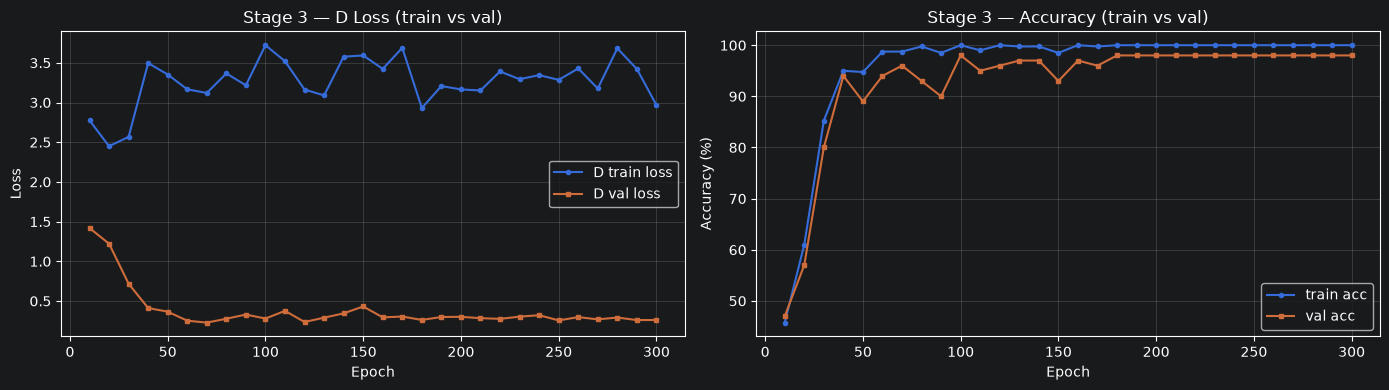

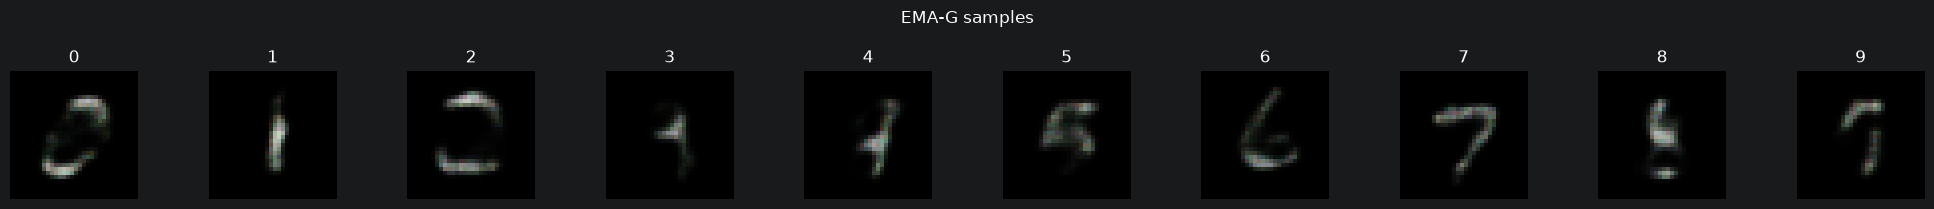

In [45]:
def tta_predict(model, x, n_views=5):
    model.eval()
    aug_fns = [
        lambda x: x,
        lambda x: weak_aug(x),
        lambda x: diff_augment(x),
        lambda x: diff_augment(weak_aug(x)),
        lambda x: diff_augment(x),
    ]
    probs = []
    with torch.no_grad():
        for fn in aug_fns[:n_views]:
            xv = fn(x.to(DEVICE))
            probs.append(F.softmax(model(xv)[:, :cfg.n_classes], dim=-1))
    return torch.stack(probs).mean(0)

def evaluate_test(model, test_imgs, test_lbls, batch=256, label=""):
    preds = []
    for i in tqdm(range(0, len(test_imgs), batch), desc=f"TTA [{label}]", leave=False):
        preds.append(tta_predict(model, test_imgs[i:i+batch]).argmax(1).cpu())
    preds = torch.cat(preds)
    acc   = (preds == test_lbls).float().mean().item()
    print(f"[{label}] ★ TEST Accuracy (final): {acc*100:.2f}%")
    return acc

print("\n=== Final Test Evaluation (1回のみ) ===")
if history:
    best_ep = max(history, key=lambda h: h[5])
    print(f"  Best val_acc: {best_ep[5]*100:.1f}%  @ epoch {best_ep[0]}")
evaluate_test(D,     test_imgs, test_lbls, label="D (no SWA)")
evaluate_test(D_swa, test_imgs, test_lbls, label="D_swa")

# 学習曲線プロット (4指標)
try:
    import matplotlib.pyplot as plt
    if history:
        eps        = [h[0] for h in history]
        d_trains   = [h[1] for h in history]
        d_vals     = [h[2] for h in history]
        train_accs = [h[4]*100 for h in history]
        val_accs   = [h[5]*100 for h in history]

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        axes[0].plot(eps, d_trains, label="D train loss", marker="o", ms=3)
        axes[0].plot(eps, d_vals,   label="D val loss",   marker="s", ms=3)
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
        axes[0].set_title("Stage 3 — D Loss (train vs val)")
        axes[0].legend(); axes[0].grid(alpha=0.3)

        axes[1].plot(eps, train_accs, label="train acc", marker="o", ms=3)
        axes[1].plot(eps, val_accs,   label="val acc",   marker="s", ms=3)
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
        axes[1].set_title("Stage 3 — Accuracy (train vs val)")
        axes[1].legend(); axes[1].grid(alpha=0.3)

        plt.tight_layout(); plt.show()
except ImportError:
    pass

# EMA-G サンプル
G_ema.eval()
with torch.no_grad():
    gs = G_ema(torch.randn(10, cfg.latent_dim, device=DEVICE),
               torch.arange(10, device=DEVICE)).cpu()
try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 10, figsize=(20, 2))
    for i, ax in enumerate(axes):
        ax.imshow(gs[i].permute(1, 2, 0).numpy(), cmap="gray")
        ax.set_title(str(i)); ax.axis("off")
    plt.suptitle("EMA-G samples", y=1.02); plt.tight_layout(); plt.show()
except ImportError:
    pass
